In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
from cycler import cycler
import importlib
import logging

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
    
import multiomic_transformer.utils.muon_preprocessing as muon_prep
import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

logging.basicConfig(level=logging.INFO, format='%(message)s')

GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"

EXPERIMENT_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS")
PROCESSED_DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/PROCESSED_DATA")
RAW_DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA")

### Set the color palette

In [4]:
color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

plt.rcParams.update({

    # figure
    "figure.figsize": (6,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

method_color_dict = {
  "Gradient Attribution": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

light_colors = [v for k,v in color_palette.items() if "light" in k]

order = ["Gradient Attribution", "LINGER", "SCENIC+", "CellOracle", "GRaNIE", "Pando", "TRIPOD", "FigR"]

## Load Ground Truth

In [5]:
def load_ground_truth(ground_truth_file: str|Path):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

gt_by_dataset_dict = {
    "Macrophage": {
        # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
        "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
        "Perturb-seq macrophage": load_ground_truth(GROUND_TRUTH_DIR / "macrophage_perturbations.csv"),
    },
    "mESC": {
        "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    "K562": {
        "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
        "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    },
    "iPSC": {
        # "ChIP-Atlas iPSC": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
        "ChIP-Atlas iPSC (1 Mb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
        # "ChIP-Atlas iPSC (100 kb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    }
}

## Load Experiments

In [6]:
def load_experiment(cell_type: str, sample_name: str, experiment_suffix: str, model_num: int, verbose: bool=False):
    experiment_name = f"{cell_type}_{sample_name}_{experiment_suffix}"

    exp = experiment_handler.load_experiment_handler(
        tdf_settings_path=PROCESSED_DATA_DIR / experiment_name / "settings.json",
        experiment_dir=EXPERIMENT_DIR,
        model_num=model_num,
        verbose=verbose,
        )
    return exp

In [29]:
importlib.reload(experiment_handler)

cell_type = "Macrophage"
sample_name = "buffer_4"
experiment_suffix = "full_pipeline"
model_num = 1

exp = load_experiment(cell_type, sample_name, experiment_suffix, model_num)
exp.experiment_name
model_str = f"{model_num:03d}"
exp.model_training_dir = Path(f"{exp.experiment_dir}/{exp.experiment_name}/model_training_{model_str}")

exp.load_grn()
exp.load_model()

gt_by_dataset_dict_sample = gt_by_dataset_dict[cell_type]

Macrophage_buffer_4_full_pipeline: Loaded existing settings


## Calculate AUROC

In [36]:
import multiomic_transformer.utils.auroc_refactored as auroc_utils
importlib.reload(auroc_utils)
importlib.reload(experiment_handler)

<module 'multiomic_transformer.utils.experiment_handler' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/experiment_handler.py'>

In [ ]:
exp.calculate_auroc_all_methods(
    exp.tdf.sample_names, 
    cell_type, 
    gt_by_dataset_dict_sample, 
    grn=exp.grn,
    use_muon_grn=True
)

Processing K562...


K562_sample_1_full_pipeline: Loaded existing settings


Processing iPSC...


iPSC_WT_D13_rep1_full_pipeline: Loaded existing settings


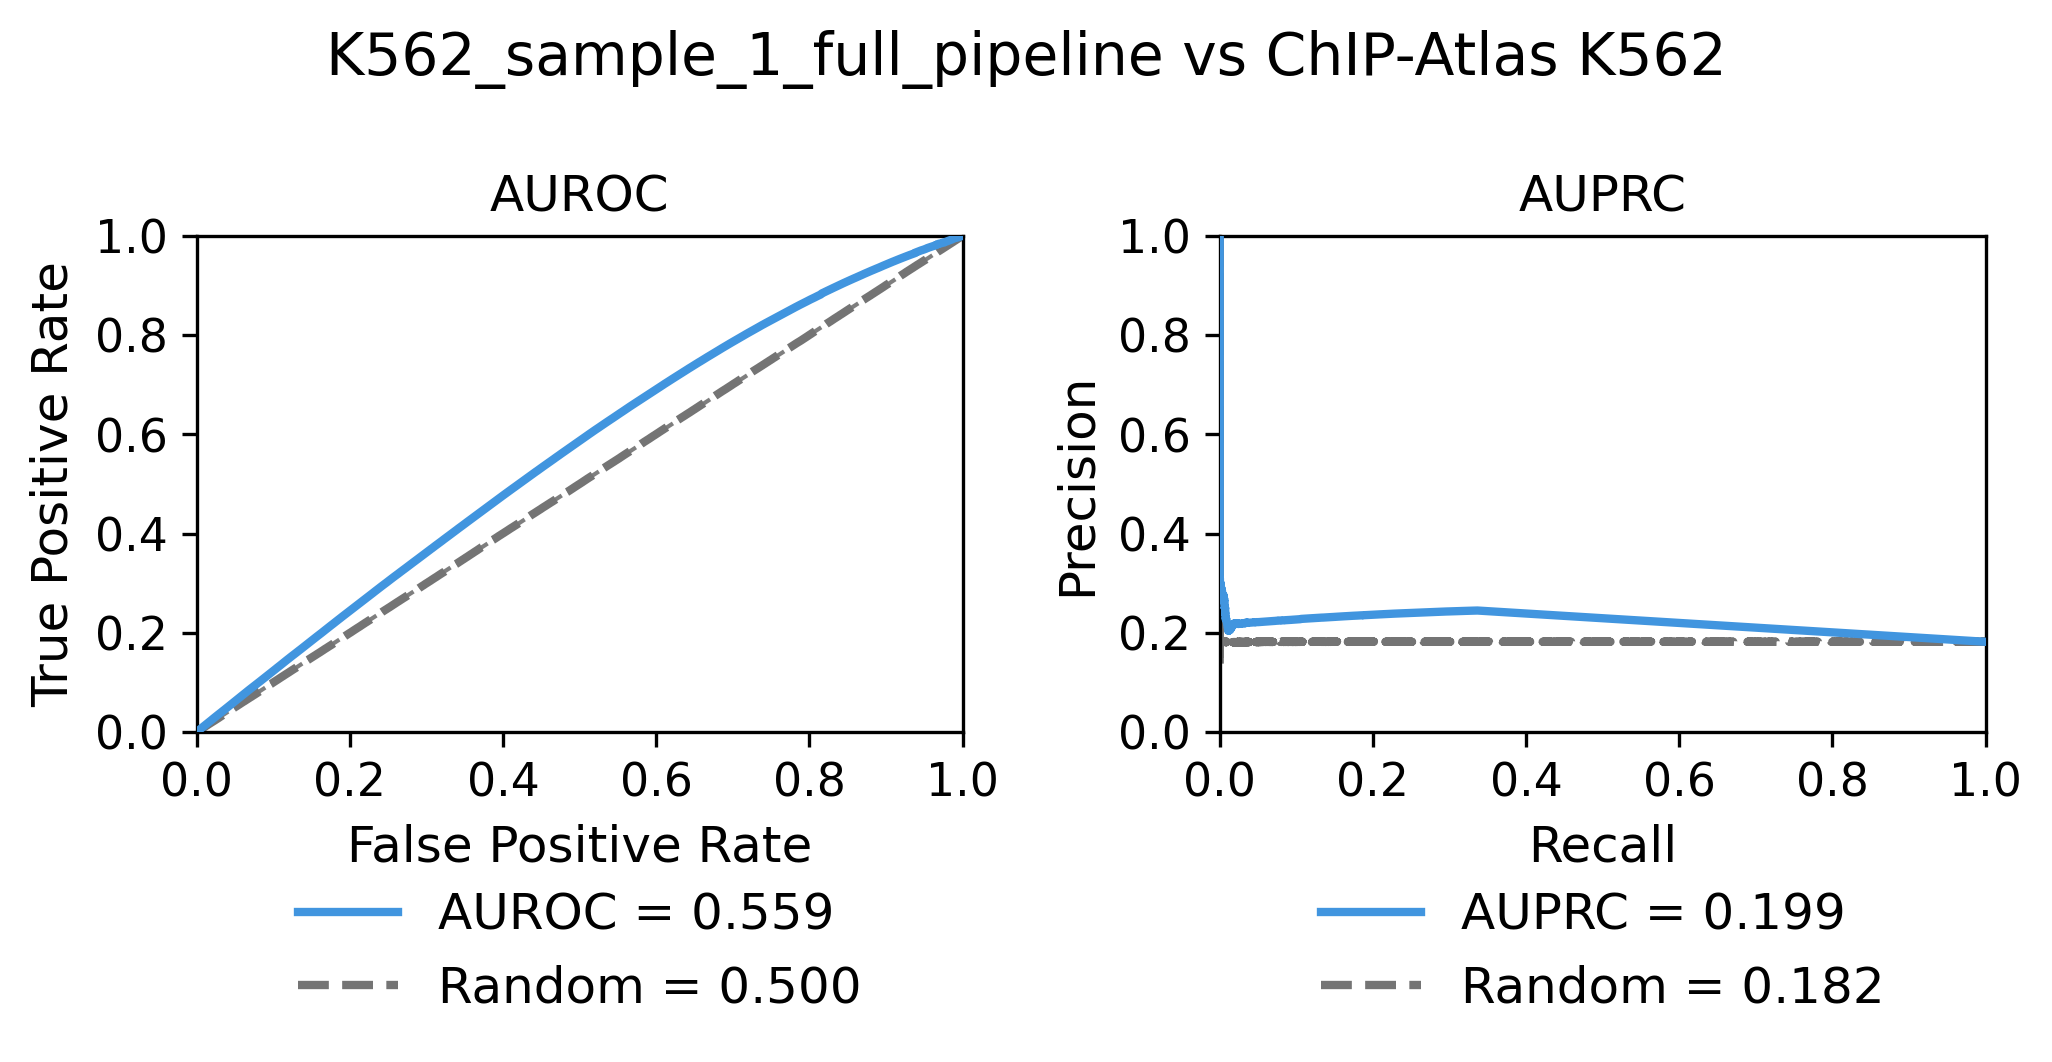

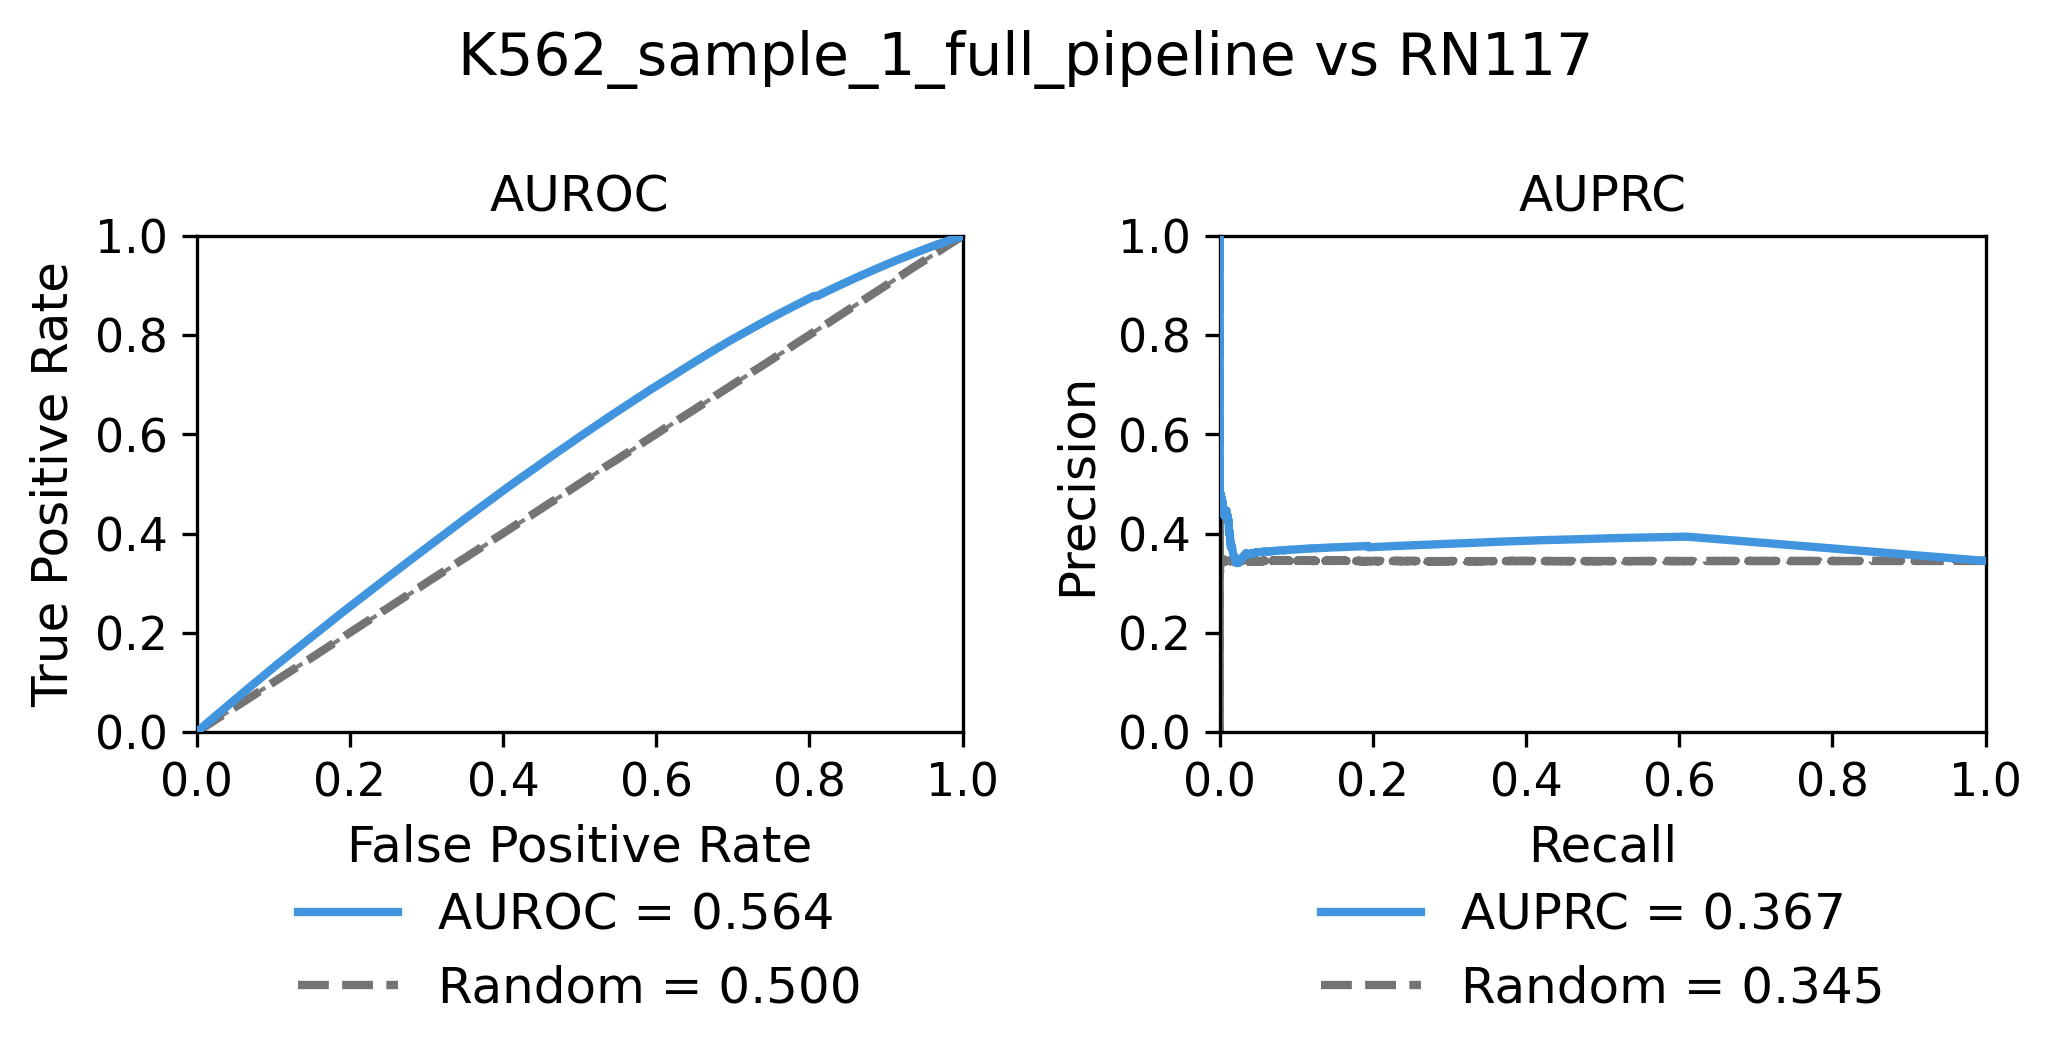

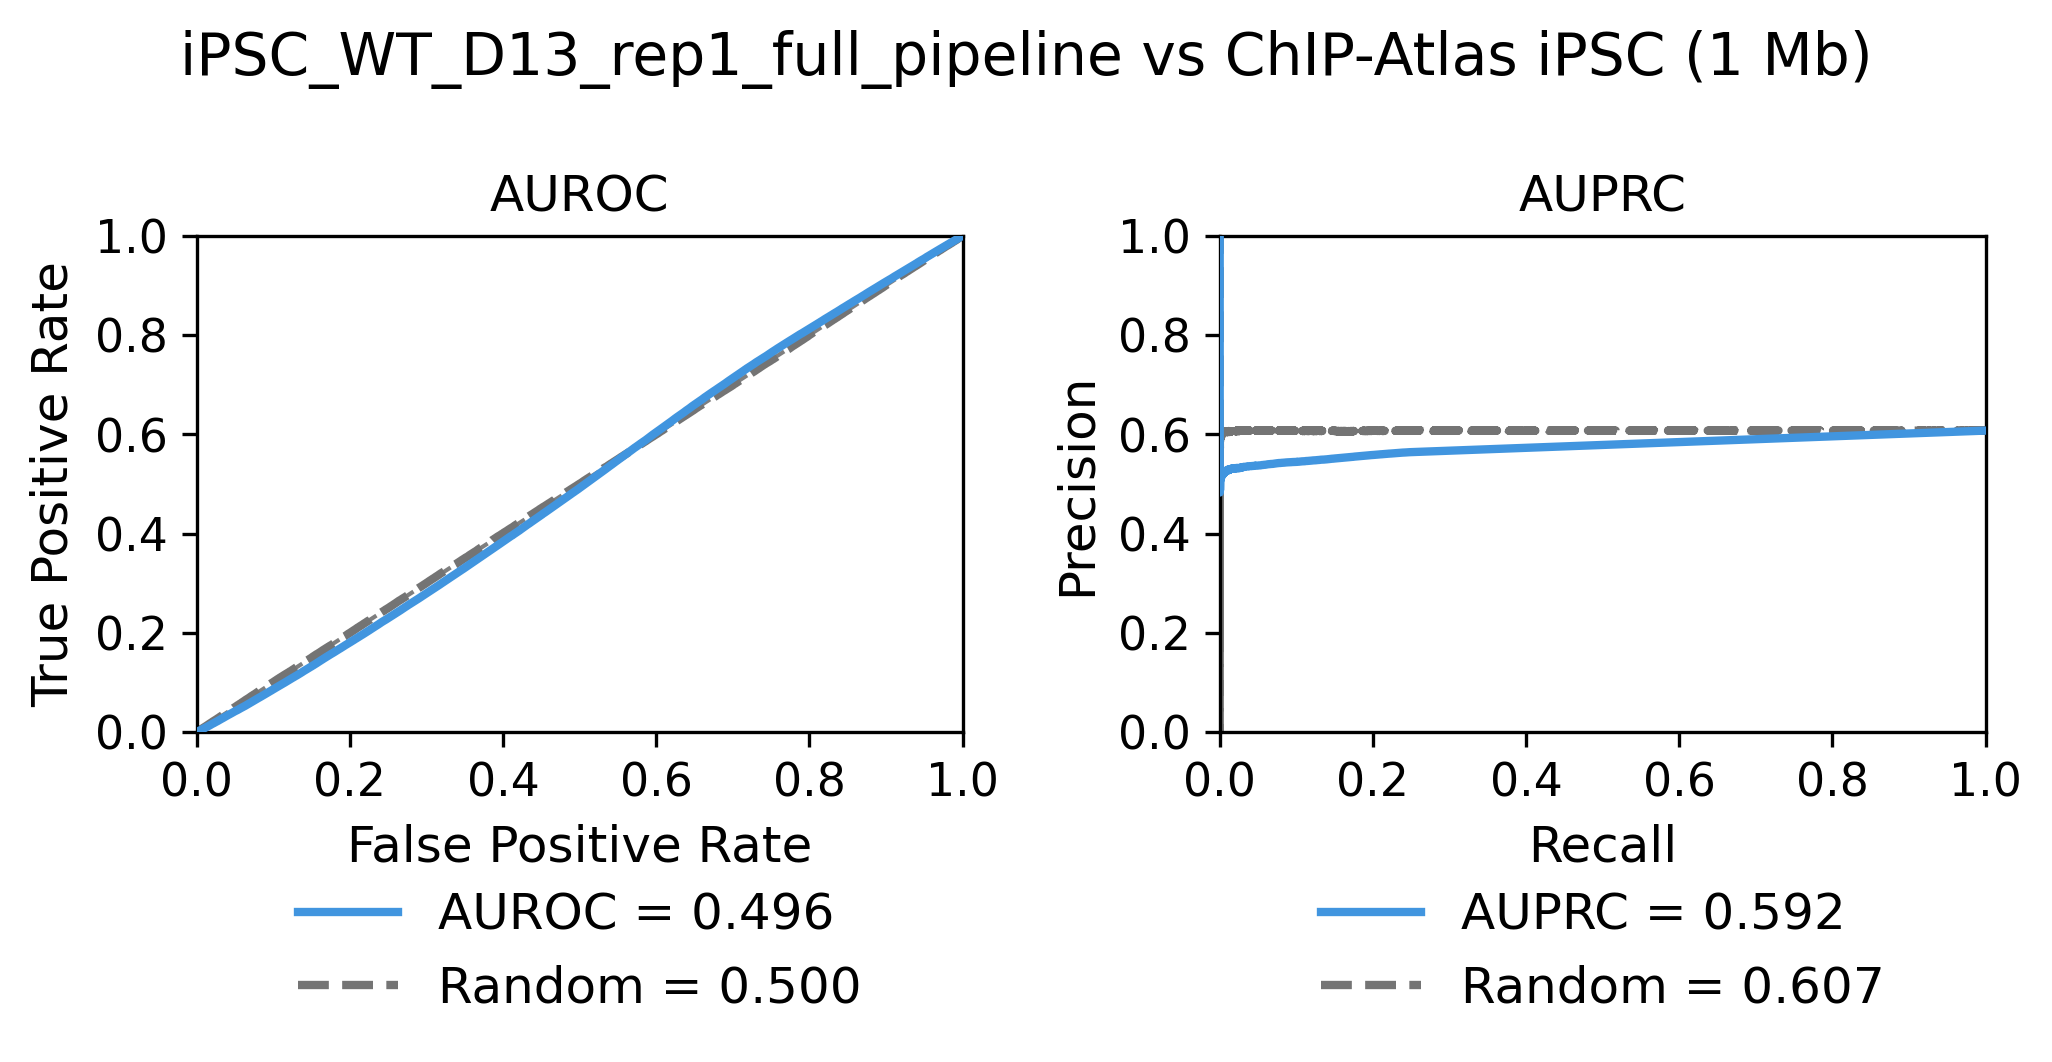

In [39]:
selected_preprocessing_experiments = [
    # ("mESC E7.5_rep1", "mESC_E7.5_rep1_full_pipeline", "mESC", 2),
    # ("mESC E7.5_rep2", "mESC_E7.5_rep2_full_pipeline", "mESC", 2),
    # ("mESC E8.5_rep1", "mESC_E8.5_rep1_full_pipeline", "mESC", 2),
    # ("mESC E8.5_rep2", "mESC_E8.5_rep2_full_pipeline", "mESC", 2),
    # ("Macrophage_buffer_1", "Macrophage_buffer_1_full_pipeline", "Macrophage", 2),
    # ("Macrophage_buffer_2", "Macrophage_buffer_2_full_pipeline", "Macrophage", 2),
    ("K562", "K562_sample_1_full_pipeline", "K562", 2),
    ("iPSC", "iPSC_WT_D13_rep1_full_pipeline", "iPSC", 2)
    ]

for sample_name, experiment_name, cell_type, model_num in selected_preprocessing_experiments:
    print(f"Processing {sample_name}...")
    
    exp = experiment_handler.load_experiment_handler(
        tdf_settings_path=PROCESSED_DATA_DIR / experiment_name / "settings.json",
        experiment_dir=EXPERIMENT_DIR,
        model_num=model_num,
        verbose=False,
        )
    exp.experiment_name
    model_str = f"{model_num:03d}"
    exp.model_training_dir = Path(f"{exp.experiment_dir}/{exp.experiment_name}/model_training_{model_str}")

    exp.load_grn()
    exp.load_model()

    gt_by_dataset_dict_sample = gt_by_dataset_dict[cell_type]

    for ground_truth_name, ground_truth in gt_by_dataset_dict_sample.items():
        auroc_auprc_fig, df = exp.plot_auroc_auprc(
            score_df=exp.grn, 
            ground_truth=ground_truth, 
            ground_truth_name=ground_truth_name
            )
        exp_fig_dir = exp.model_training_dir / "figures"
        exp_fig_dir.mkdir(exist_ok=True)
        auroc_auprc_fig.savefig(exp_fig_dir / f"{exp.experiment_name}_{ground_truth_name}_auroc_auprc.png")


----- GRN Size -----
Number of unique TFs: 1,148
Number of unique TGs: 12,328
Number of edges: 14,152,544

----- GRN Overlap with Ground Truth -----
ChIP-Atlas macrophage
  - TF Overlap: 15 (24 in GT)
  - TG Overlap: 11,940 (37,851 in GT)
  - Edge Overlap: 0 (2,500,303 in GT)
Perturb-seq macrophage
  - TF Overlap: 18 (18 in GT)
  - TG Overlap: 1,958 (3,247 in GT)
  - Edge Overlap: 0 (4,467 in GT)

----- AUROC -----
Median Pooled AUROC: 0.514
Median Per-TF AUROC: 0.523

----- Saving Experiment -----
Experiment saved to /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS


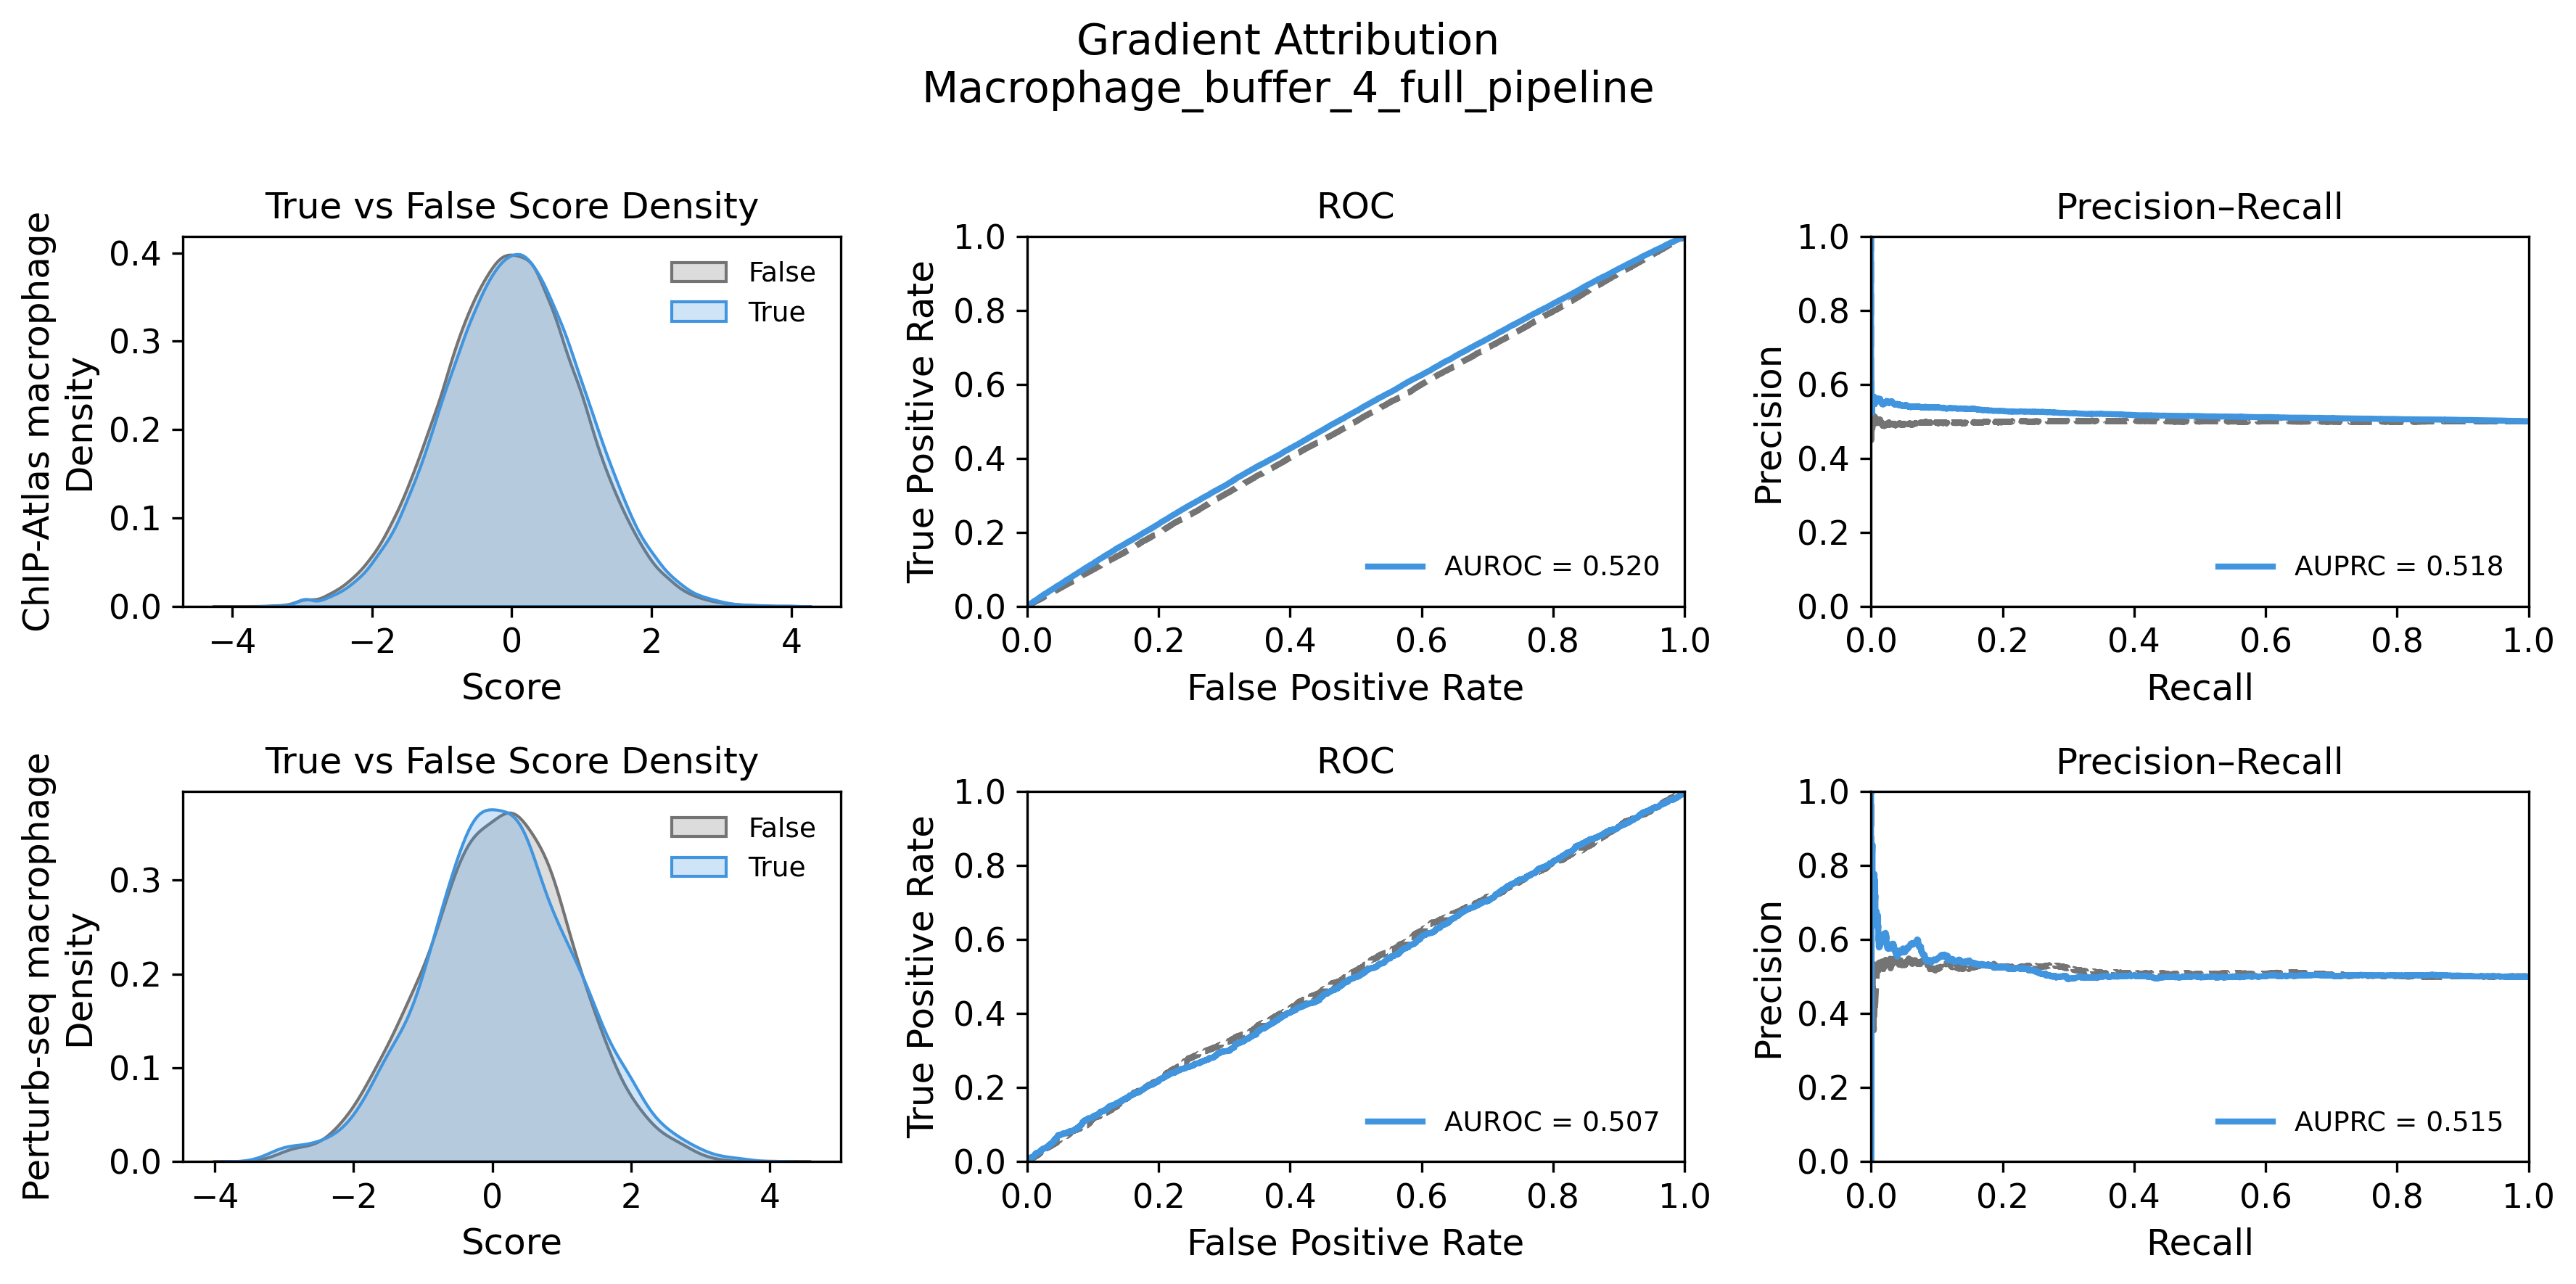

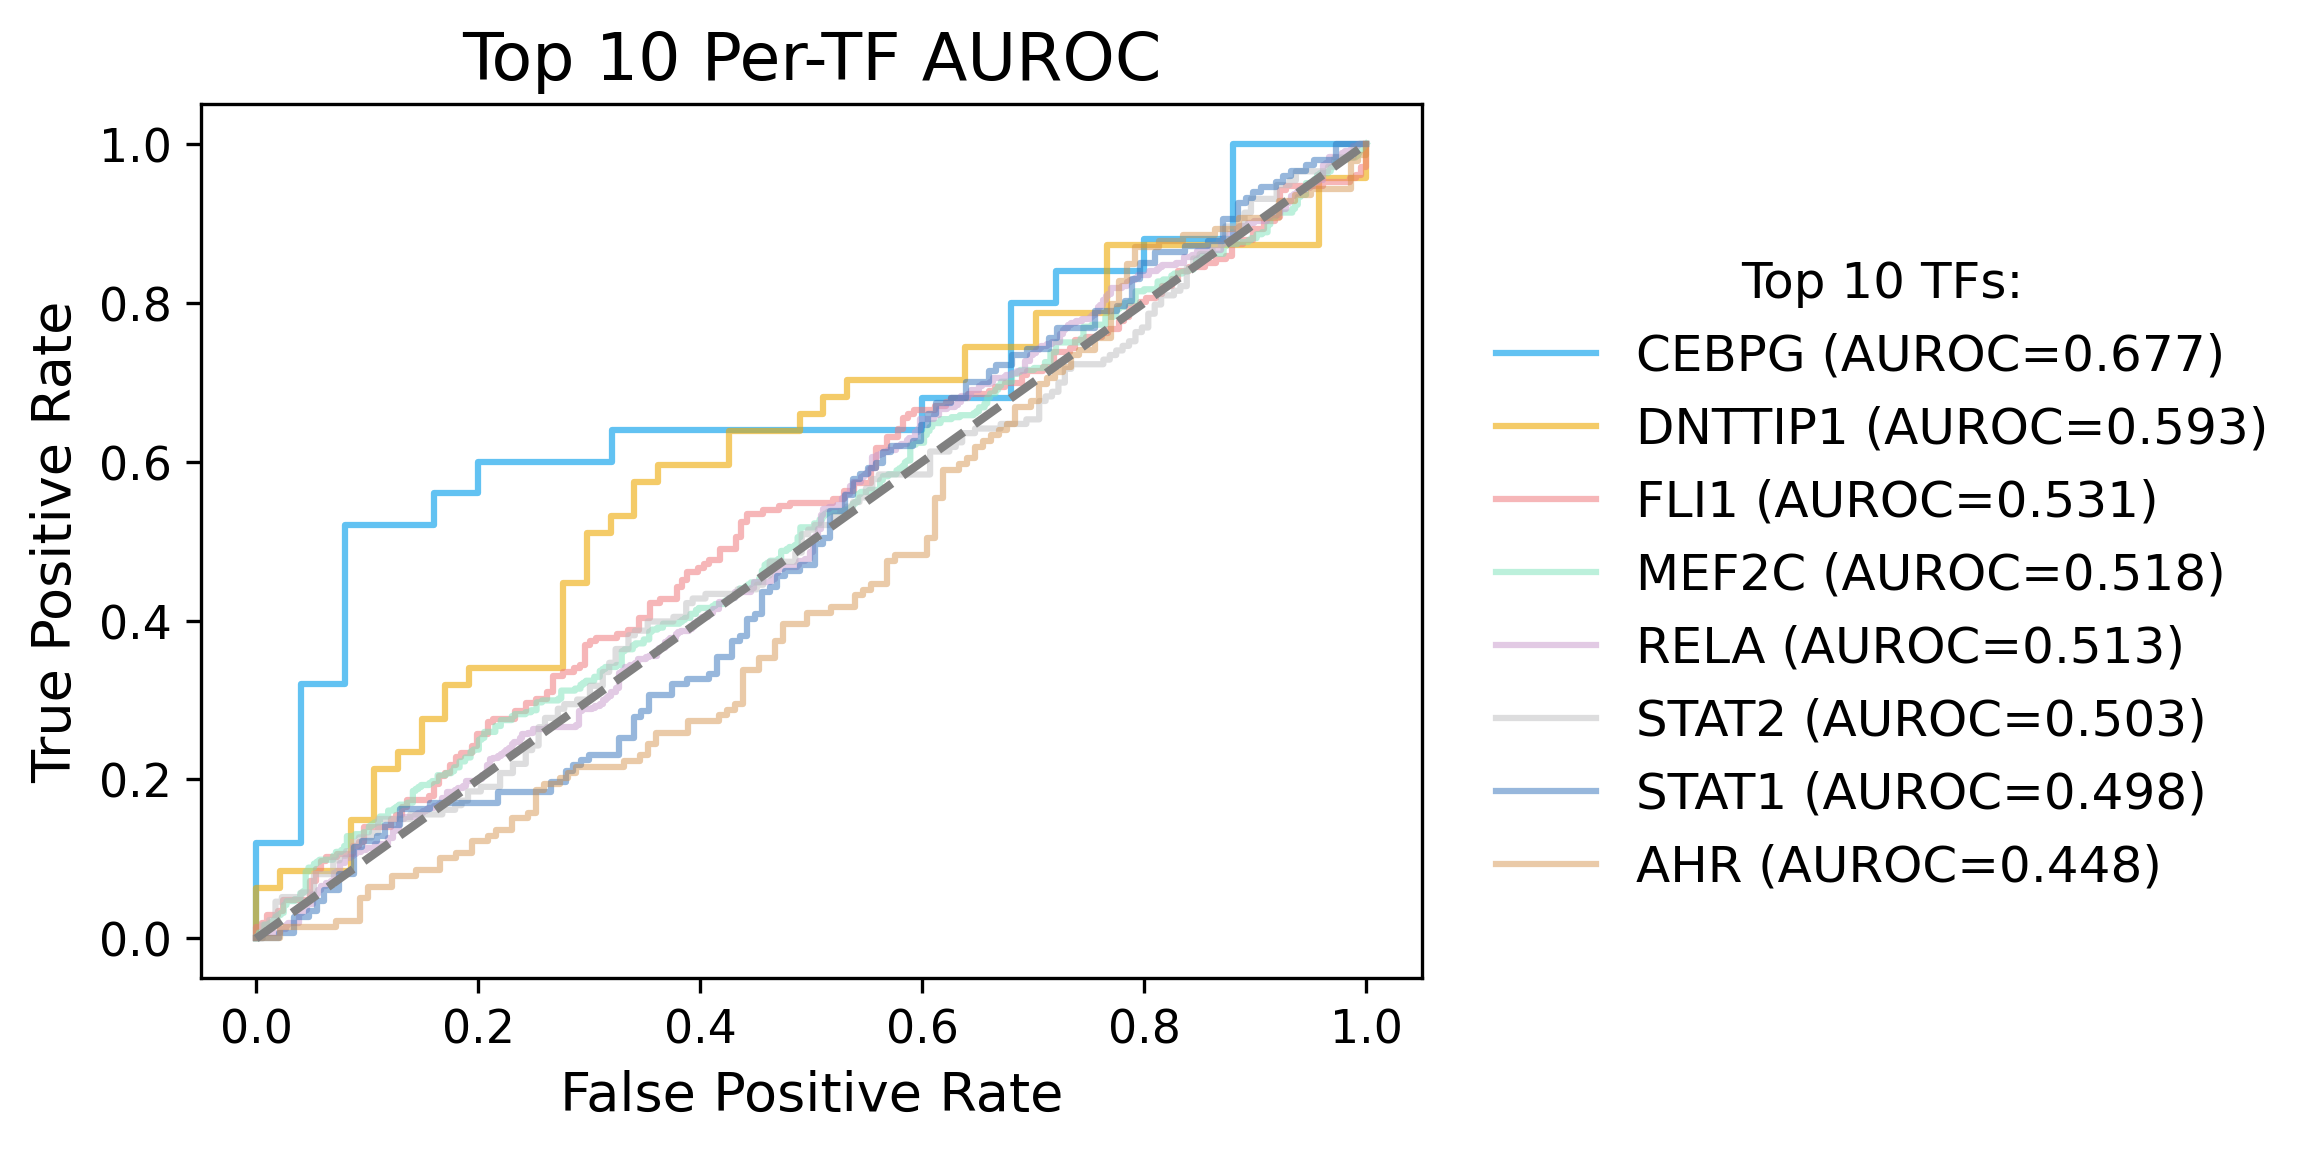

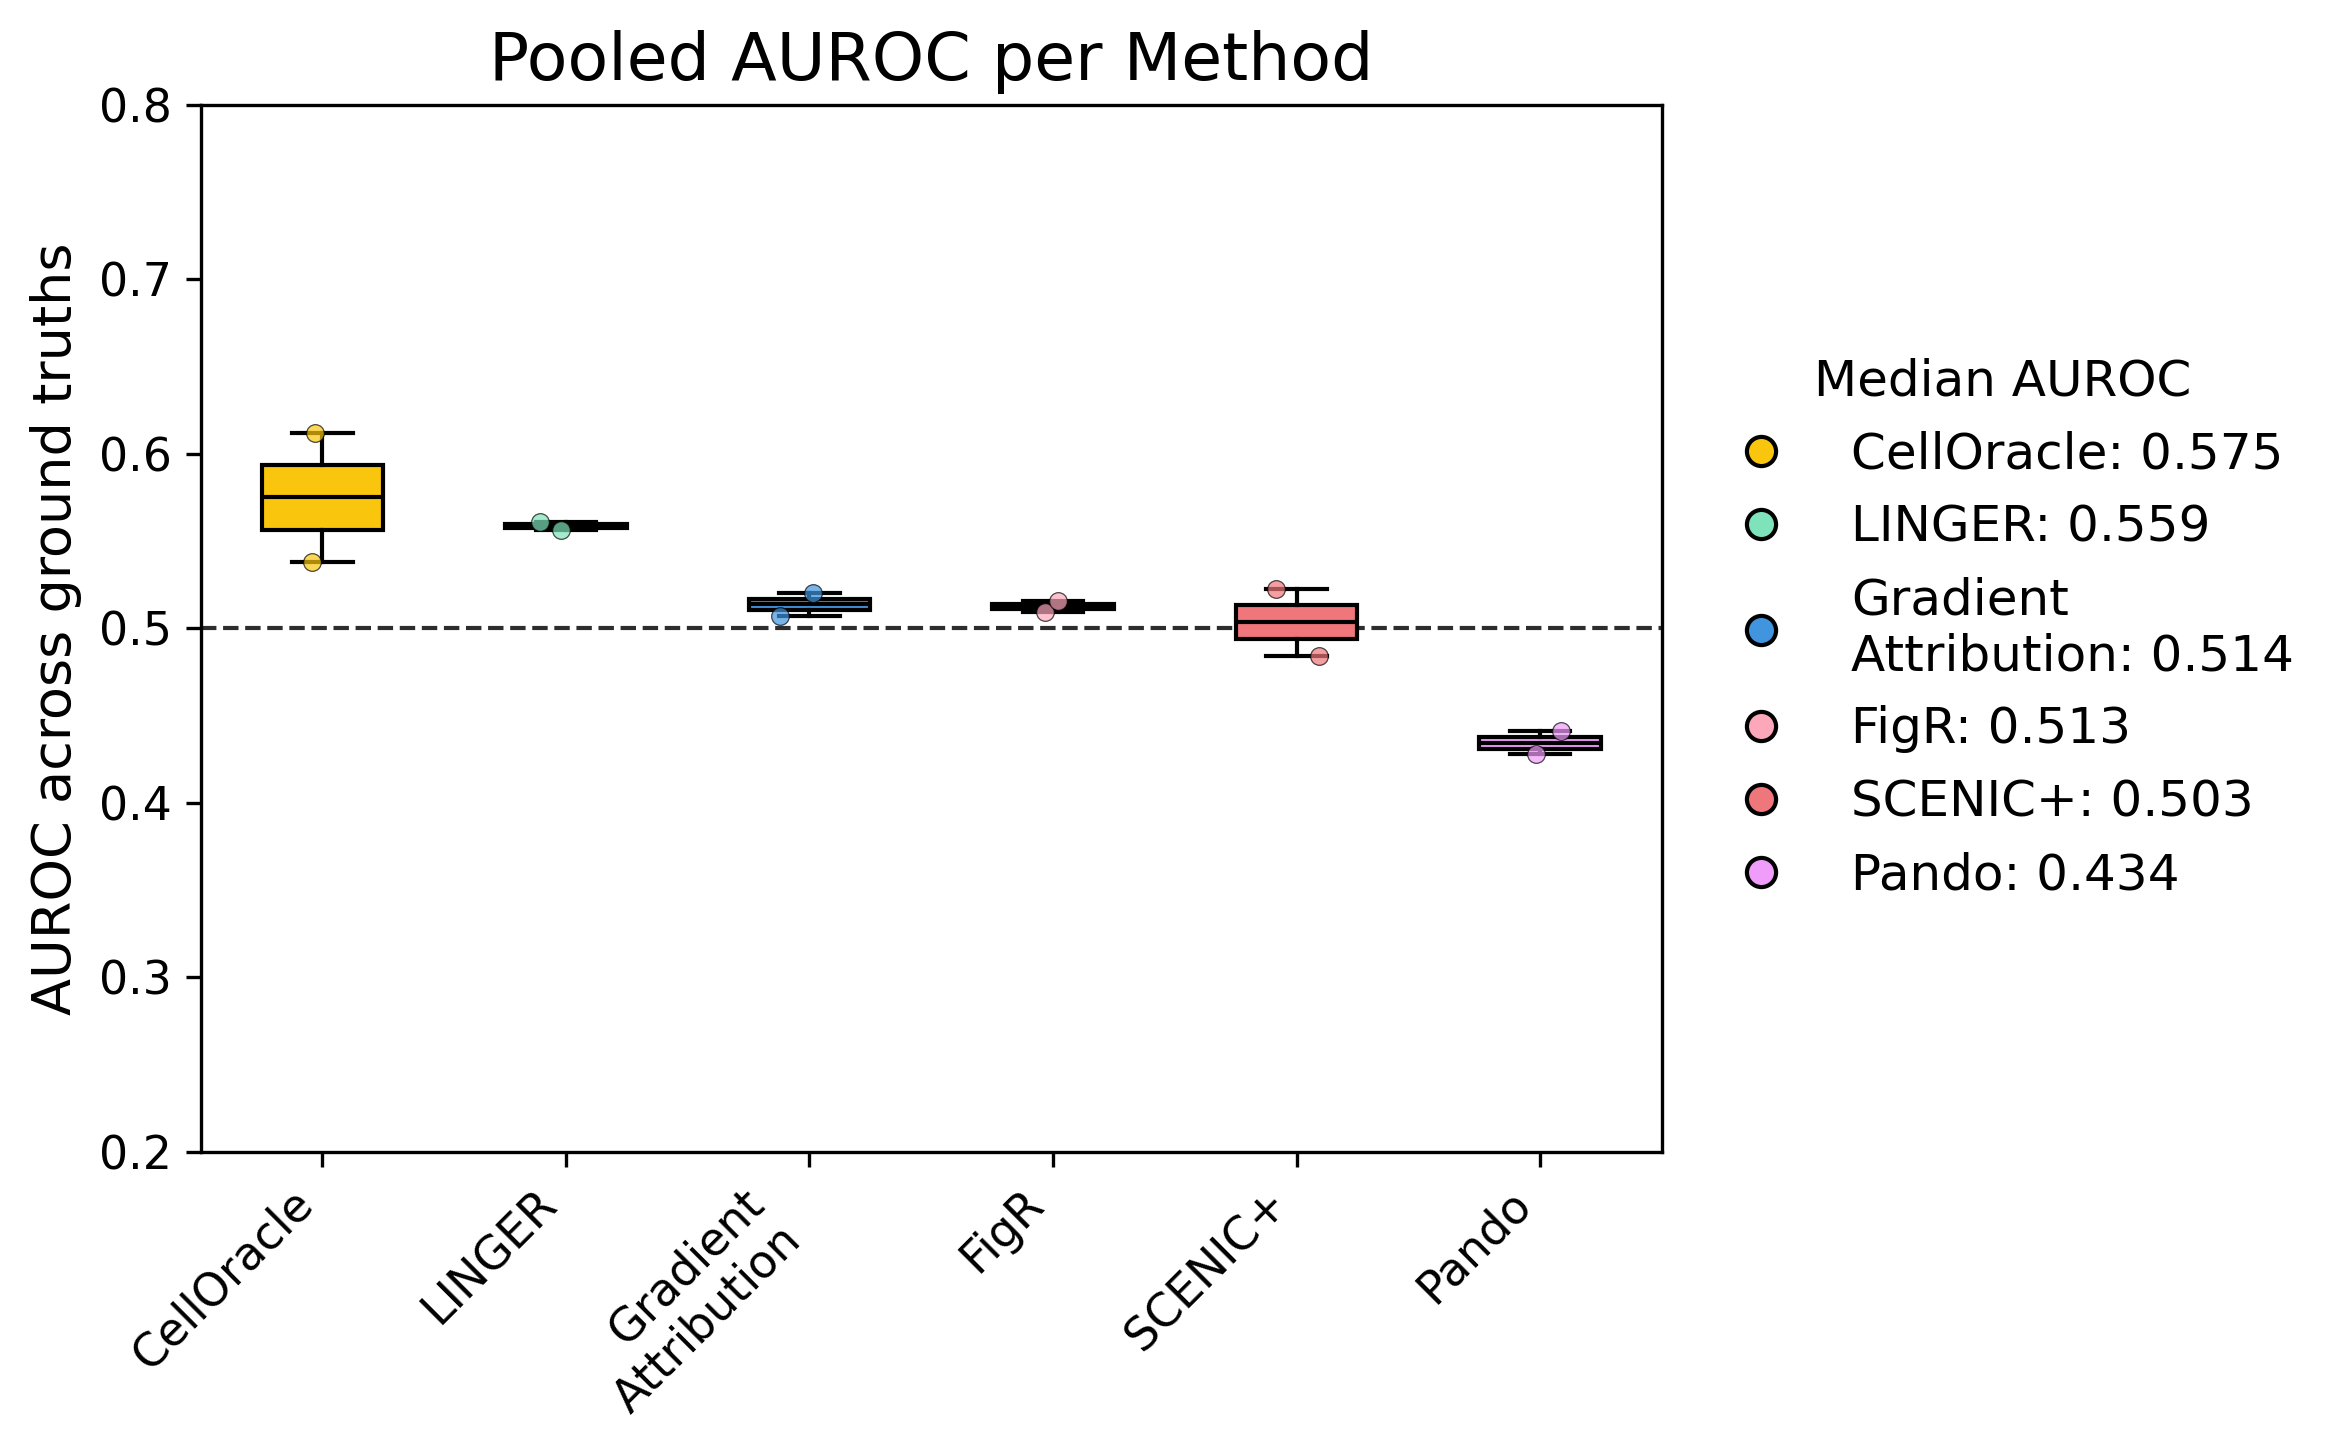

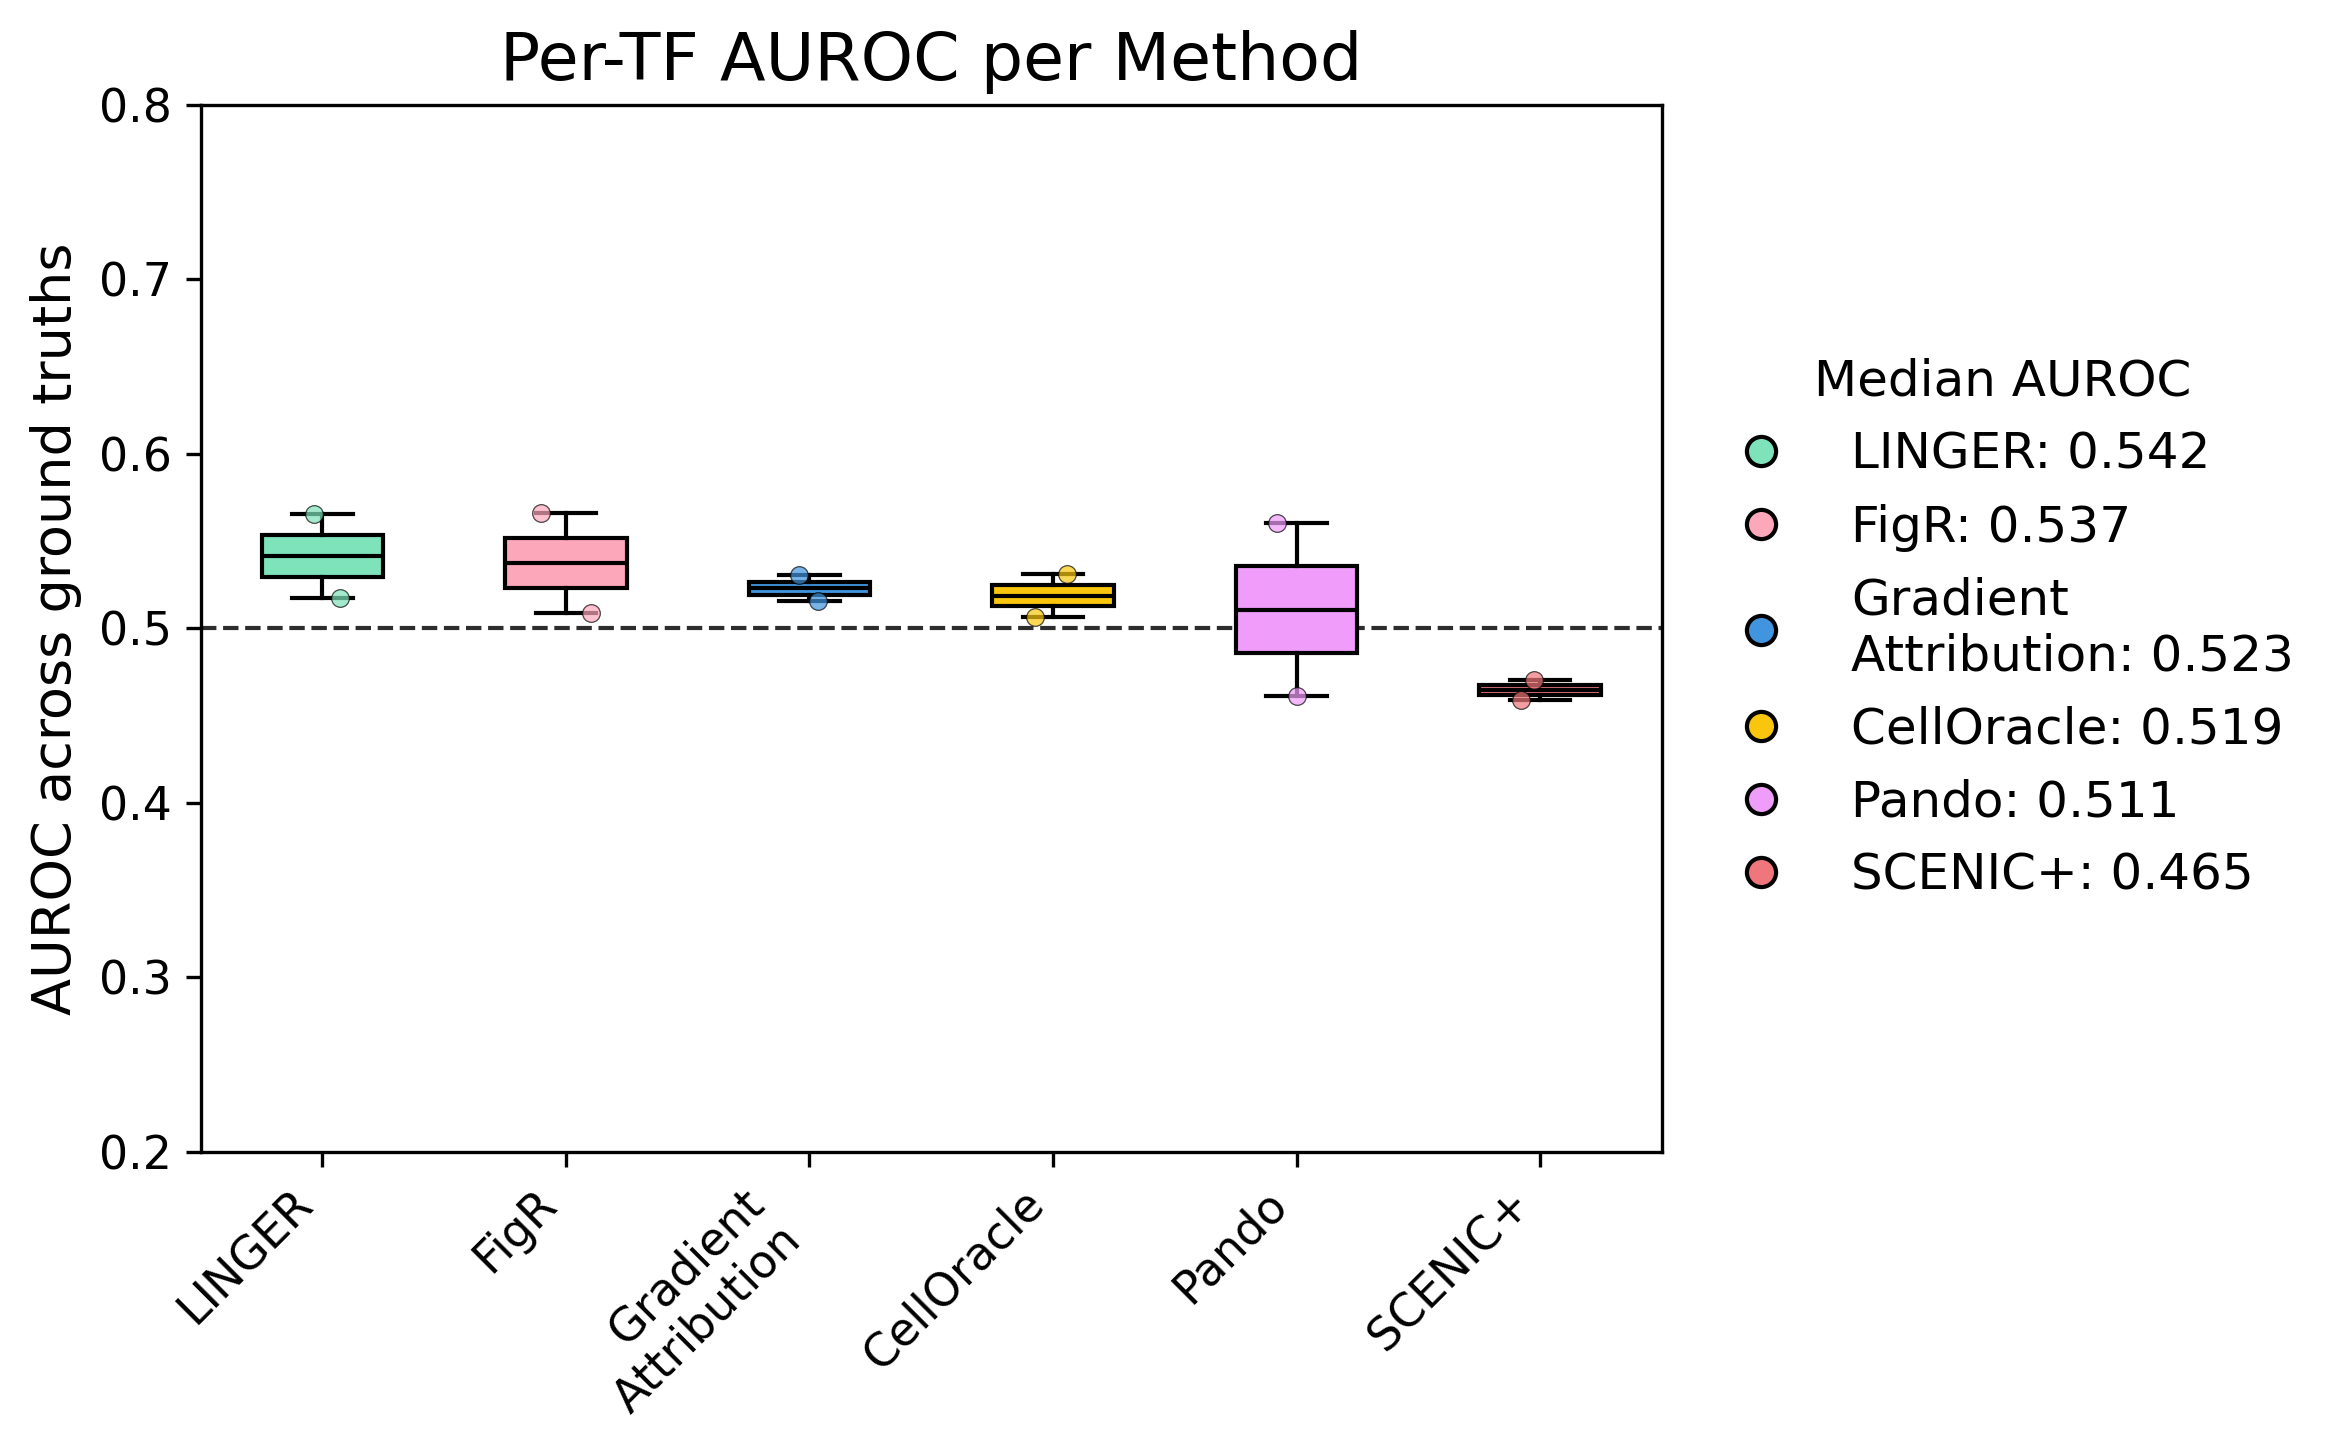

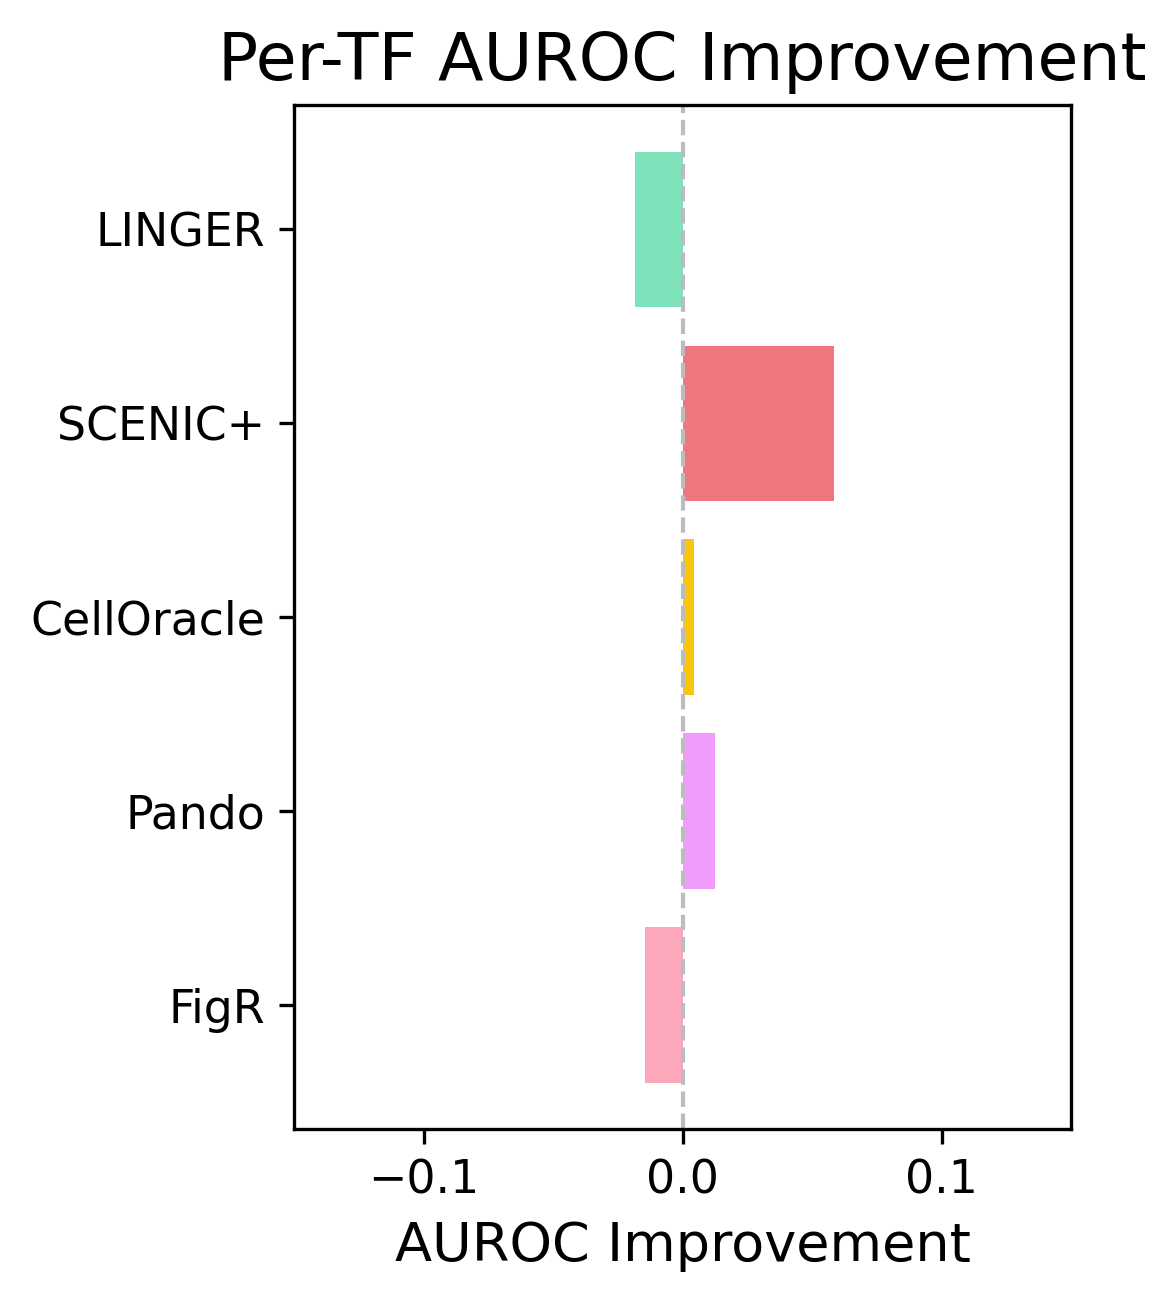

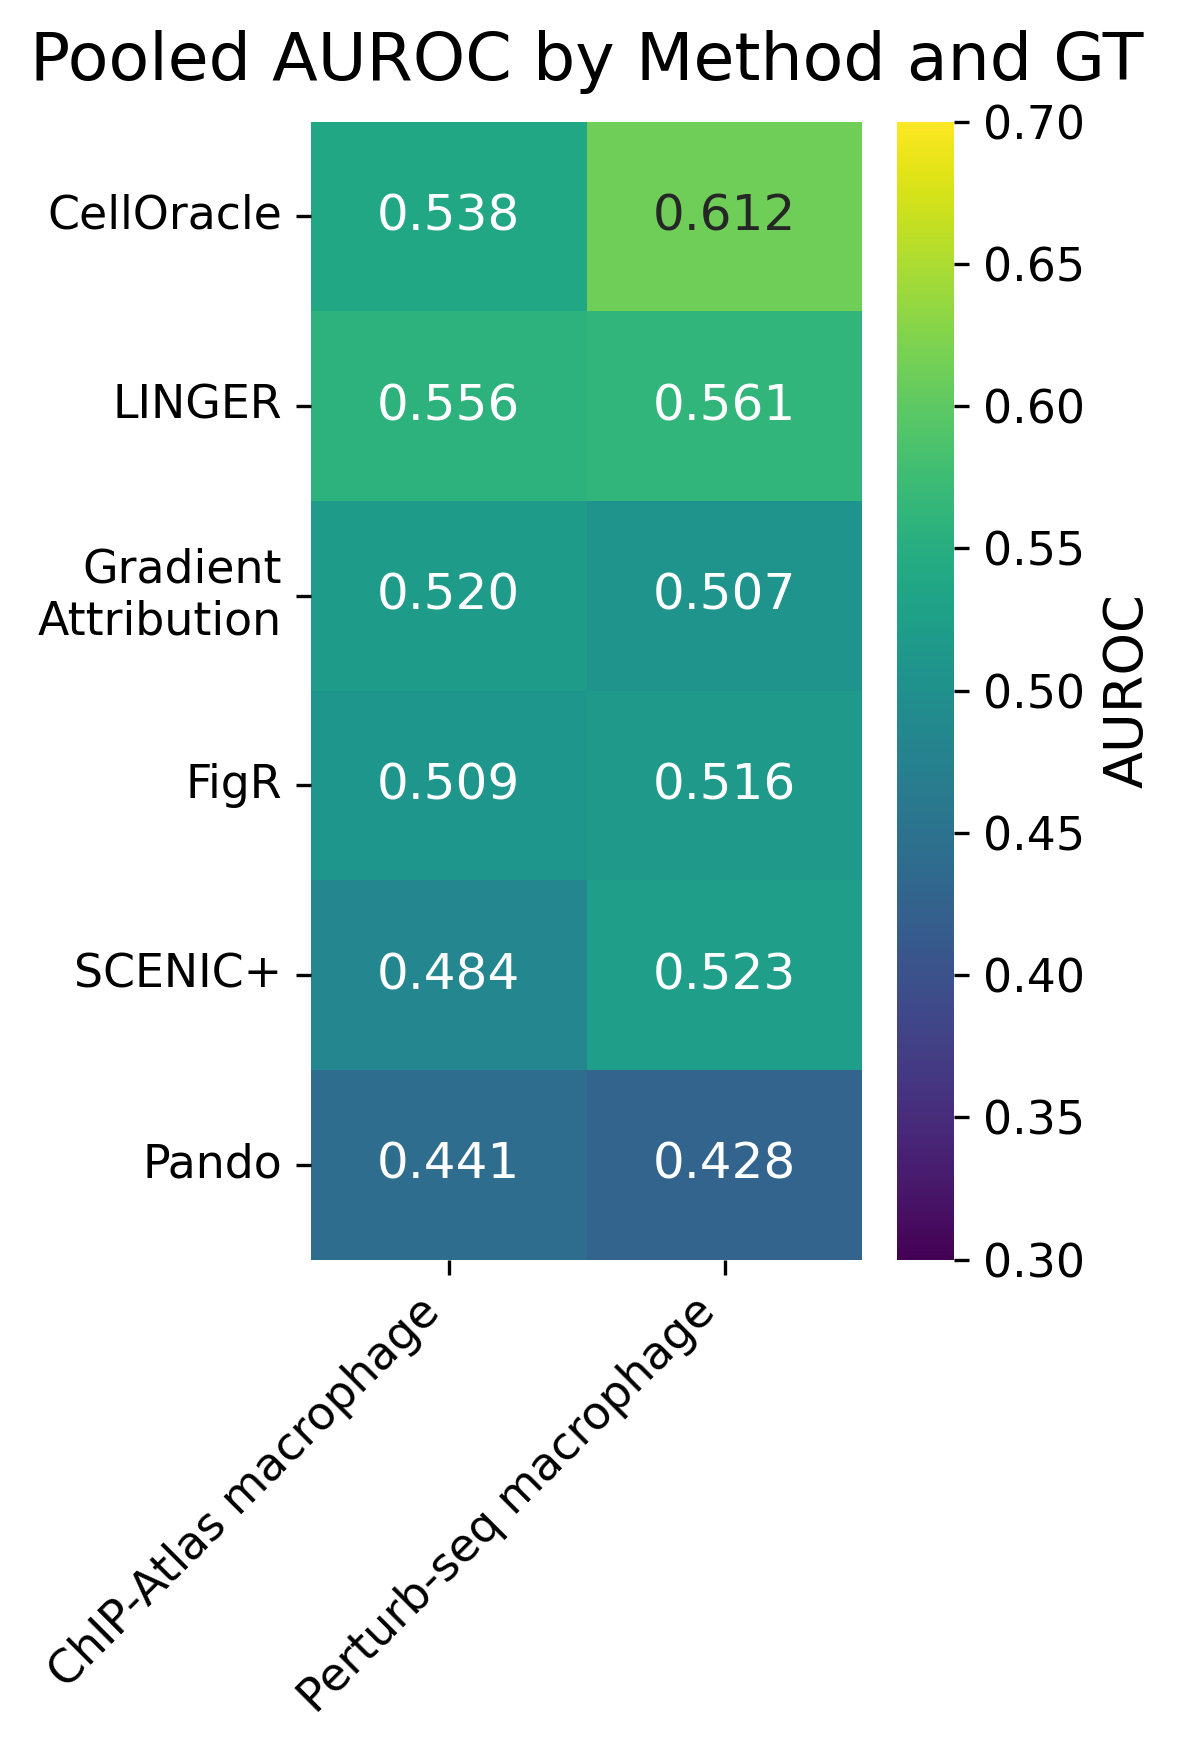

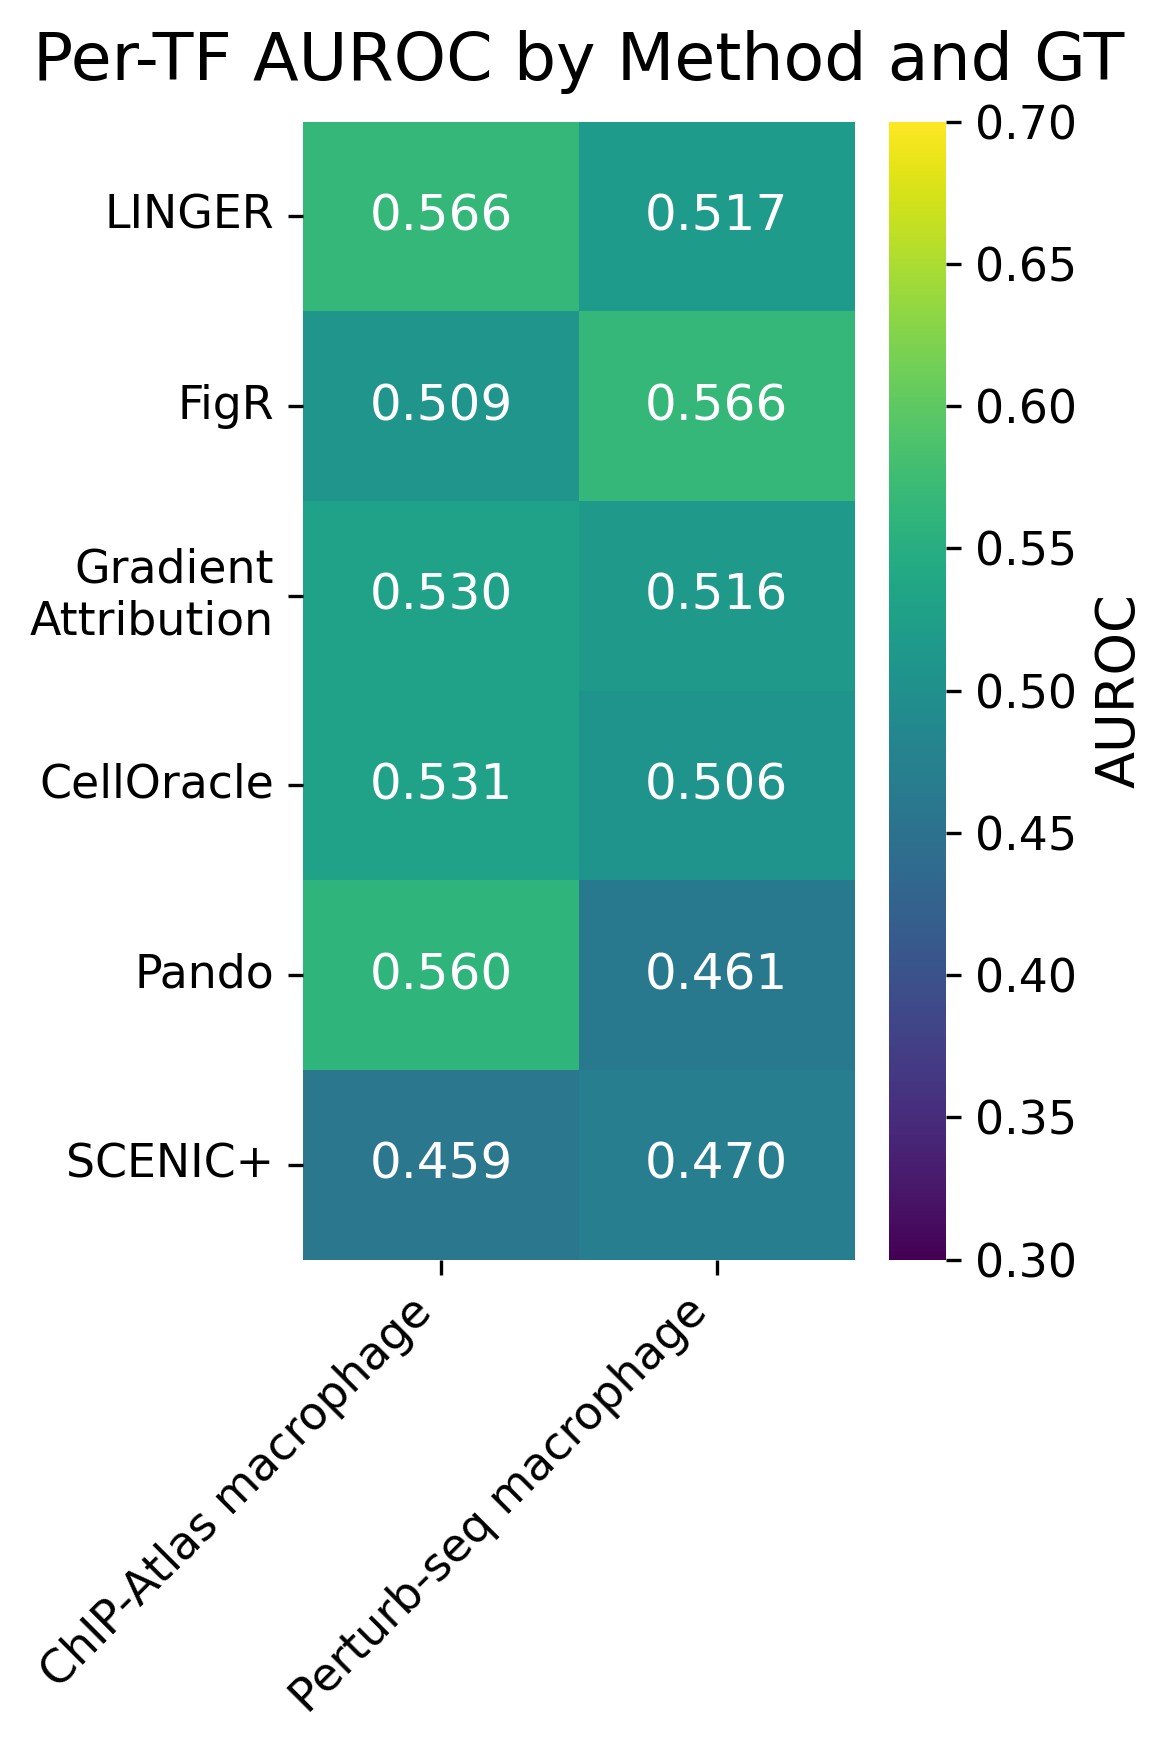

In [10]:
fig = exp.plot_hist_roc_pr(
exp.grn, 
gt_by_dataset_dict_sample, 
method_name="Gradient Attribution", 
)

# exp.epoch_log_df.iloc[-1]
# final_r2u = exp.epoch_log_df.iloc[-1]["r2_unscaled"]
# final_r2s = exp.epoch_log_df.iloc[-1]["r2_scaled"]
# avg_epoch_time = exp.epoch_log_df["epoch_time_s"].mean()

# logging.info(f"\n\n--- Model Training Summary ---")
# logging.info(f"Final R2 (unscaled): {final_r2u:.4f}")
# logging.info(f"Final R2 (scaled): {final_r2s:.4f}")
# logging.info(f"Average Epoch Time: {avg_epoch_time:.2f} seconds")
# logging.info(f"Number of Metacells: {exp.tdf.num_metacells:,}")
# logging.info(f"Number of Windows: {exp.tdf.num_windows:,}\n")

num_edges = len(exp.grn)
num_tfs = exp.grn["Source"].nunique()
num_tgs = exp.grn["Target"].nunique()

logging.info(f"\n----- GRN Size -----")
logging.info(f"Number of unique TFs: {num_tfs:,}")
logging.info(f"Number of unique TGs: {num_tgs:,}")
logging.info(f"Number of edges: {num_edges:,}")

logging.info(f"\n----- GRN Overlap with Ground Truth -----")
for ground_truth_name, ground_truth in gt_by_dataset_dict_sample.items():
    exp.report_grn_overlap_with_gt(ground_truth_name, ground_truth)

logging.info(f"\n----- AUROC -----")
per_tf_df_all =  pd.read_csv(exp.model_training_dir / "per_tf_auroc_auprc_results.csv")
pooled_df_all = pd.read_csv(exp.model_training_dir / "pooled_auroc_auprc_results.csv")

per_tf_plot_df = (
    per_tf_df_all.dropna(subset=["auroc"])
    .groupby(['method', 'gt'], as_index=False)
    .agg(
        auroc=('auroc', 'median'),
    )
)

pooled_df_median_auroc = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]["auroc"].median()
per_tf_median_auroc = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]["auroc"].median()

logging.info(f"Median Pooled AUROC: {pooled_df_median_auroc:.3f}")
logging.info(f"Median Per-TF AUROC: {per_tf_median_auroc:.3f}")

fig_dir = exp.model_training_dir / "figures"
fig_dir.mkdir(exist_ok=True)

name = exp.experiment_name.replace("_", " ")
per_tf_plot, per_tf_df, tf_curves = exp.plot_top_n_tf_roc_curves(
    exp.grn, 
    gt_by_dataset_dict_sample[ground_truth_name], 
    ground_truth_name, 
    exp, 
    method_name="Gradient Attribution", 
    num_top_tfs_to_plot=10,
    min_edges=50,
    min_pos=10,
    balance=True,
    name_clean=name,
    override_title=f"Top 10 Per-TF AUROC"
    )
per_tf_plot.savefig(fig_dir / f"top_10_per_tf_auroc.png", dpi=250, bbox_inches="tight")
per_tf_plot.show()

pooled_auroc_boxplot_fig = exp._plot_all_results_auroc_boxplot(
    pooled_df_all,
    per_tf=False,
    ylim=(0.2, 0.8),
    override_title=f"Pooled AUROC per Method",
    method_color_dict=exp.method_color_dict
)
pooled_auroc_boxplot_fig.savefig(fig_dir / f"pooled_auroc_boxplot.png", dpi=250, bbox_inches="tight")
pooled_auroc_boxplot_fig.show()

per_tf_auroc_boxplot_fig = exp._plot_all_results_auroc_boxplot(
    per_tf_plot_df, 
    per_tf=True,
    ylim=(0.2, 0.8),
    override_title=f"Per-TF AUROC per Method",
    method_color_dict=exp.method_color_dict
    )
per_tf_auroc_boxplot_fig.savefig(fig_dir / f"per_tf_auroc_boxplot.png", dpi=250, bbox_inches="tight")
per_tf_auroc_boxplot_fig.show()

relative_improvement_fig = exp.plot_relative_improvement(
    per_tf_plot_df, 
    exp.experiment_name,
    override_title=f"Per-TF AUROC Improvement",
    )
relative_improvement_fig.savefig(fig_dir / f"relative_improvement.png", dpi=250, bbox_inches="tight")
relative_improvement_fig.show()

pooled_auroc_heatmap_fig = exp.plot_method_gt_heatmap(
    pooled_df_all, 
    per_tf=False,
    x_scale=1.2,
    y_scale=1.0,
    override_title=f"Pooled AUROC by Method and GT"
    )
pooled_auroc_heatmap_fig.savefig(fig_dir / f"pooled_auroc_heatmap.png", dpi=250, bbox_inches="tight")
pooled_auroc_heatmap_fig.show()

per_tf_auroc_heatmap_fig = exp.plot_method_gt_heatmap(
    per_tf_plot_df, 
    per_tf=True,
    x_scale=1.2,
    y_scale=1.0,
    override_title=f"Per-TF AUROC by Method and GT"
    )
per_tf_auroc_heatmap_fig.savefig(fig_dir / f"per_tf_auroc_heatmap.png", dpi=250, bbox_inches="tight")
per_tf_auroc_heatmap_fig.show()

# true_vs_predicted_fig = exp.plot_true_vs_predicted_tg_expression(
#     num_batches=50, 
#     set_axis_logscale=False,
#     title=f"Predicted vs True TG Expression"
#     )
# true_vs_predicted_fig.savefig(fig_dir / f"true_vs_predicted.png", dpi=250, bbox_inches="tight")
# true_vs_predicted_fig.show()

logging.info(f"\n----- Saving Experiment -----")
exp.save_handler()
logging.info(f"Experiment saved to {exp.experiment_dir}")

In [11]:
from PIL import Image

def combine_images_with_spans(
    layout,
    space,
    fig_dir,
    output_name="combined_images.png",
    bg_color=(255, 255, 255, 255),
):
    """
    Combine images into a manually positioned grid with optional row/column spanning.

    Parameters
    ----------
    layout : dict
        Dictionary mapping image path -> config dict

        Required keys per image:
            row : int
            col : int

        Optional keys per image:
            scale : float, default 1.0
            rowspan : int, default 1
            colspan : int, default 1

        Example:
        {
            Path("a.png"): {"row": 0, "col": 0, "scale": 1.0, "rowspan": 1, "colspan": 2},
            Path("b.png"): {"row": 0, "col": 2, "scale": 0.8},
            Path("c.png"): {"row": 1, "col": 0, "scale": 1.1, "rowspan": 2, "colspan": 2},
        }

    space : int
        Pixels between grid cells.
    fig_dir : Path
        Output directory.
    output_name : str
        Output filename.
    bg_color : tuple
        RGBA background color.

    Returns
    -------
    Path
        Path to the saved combined image.
    """
    items = []

    # Load images and parse layout
    for image_path, cfg in layout.items():
        row = cfg["row"]
        col = cfg["col"]
        scale = cfg.get("scale", 1.0)
        rowspan = cfg.get("rowspan", 1)
        colspan = cfg.get("colspan", 1)

        if rowspan < 1 or colspan < 1:
            raise ValueError(f"{image_path}: rowspan and colspan must be >= 1")

        img = Image.open(image_path).convert("RGBA")
        new_width = max(1, int(img.width * scale))
        new_height = max(1, int(img.height * scale))
        img_resized = img.resize((new_width, new_height), Image.LANCZOS)

        items.append({
            "path": image_path,
            "row": row,
            "col": col,
            "rowspan": rowspan,
            "colspan": colspan,
            "img": img_resized,
            "width": new_width,
            "height": new_height,
        })

    if not items:
        raise ValueError("Layout is empty.")

    n_rows = max(item["row"] + item["rowspan"] for item in items)
    n_cols = max(item["col"] + item["colspan"] for item in items)

    # Check for overlapping occupied cells
    occupied = {}
    for item in items:
        for r in range(item["row"], item["row"] + item["rowspan"]):
            for c in range(item["col"], item["col"] + item["colspan"]):
                key = (r, c)
                if key in occupied:
                    raise ValueError(
                        f"Overlap detected: {item['path']} overlaps with {occupied[key]} at cell {key}"
                    )
                occupied[key] = item["path"]

    # Compute minimum column widths and row heights
    # Start from single-cell requirements
    col_widths = [0] * n_cols
    row_heights = [0] * n_rows

    for item in items:
        if item["colspan"] == 1:
            col_widths[item["col"]] = max(col_widths[item["col"]], item["width"])
        if item["rowspan"] == 1:
            row_heights[item["row"]] = max(row_heights[item["row"]], item["height"])

    # Expand widths/heights as needed for spanned items
    # A simple iterative pass is usually enough for plotting layouts
    for _ in range(10):
        changed = False

        for item in items:
            # Width across spanned columns, including inter-column spaces inside the span
            current_span_width = (
                sum(col_widths[item["col"]: item["col"] + item["colspan"]])
                + space * (item["colspan"] - 1)
            )
            if current_span_width < item["width"]:
                deficit = item["width"] - current_span_width
                add_per_col = deficit / item["colspan"]
                for c in range(item["col"], item["col"] + item["colspan"]):
                    new_val = int(round(col_widths[c] + add_per_col))
                    if new_val > col_widths[c]:
                        col_widths[c] = new_val
                        changed = True

            # Height across spanned rows, including inter-row spaces inside the span
            current_span_height = (
                sum(row_heights[item["row"]: item["row"] + item["rowspan"]])
                + space * (item["rowspan"] - 1)
            )
            if current_span_height < item["height"]:
                deficit = item["height"] - current_span_height
                add_per_row = deficit / item["rowspan"]
                for r in range(item["row"], item["row"] + item["rowspan"]):
                    new_val = int(round(row_heights[r] + add_per_row))
                    if new_val > row_heights[r]:
                        row_heights[r] = new_val
                        changed = True

        if not changed:
            break

    # Compute canvas size
    background_width = sum(col_widths) + space * (n_cols - 1)
    background_height = sum(row_heights) + space * (n_rows - 1)

    background = Image.new("RGBA", (background_width, background_height), bg_color)

    # Precompute grid start coordinates
    col_starts = []
    x = 0
    for w in col_widths:
        col_starts.append(x)
        x += w + space

    row_starts = []
    y = 0
    for h in row_heights:
        row_starts.append(y)
        y += h + space

    # Paste each image centered within its spanned rectangle
    for item in items:
        x0 = col_starts[item["col"]]
        y0 = row_starts[item["row"]]

        span_width = (
            sum(col_widths[item["col"]: item["col"] + item["colspan"]])
            + space * (item["colspan"] - 1)
        )
        span_height = (
            sum(row_heights[item["row"]: item["row"] + item["rowspan"]])
            + space * (item["rowspan"] - 1)
        )

        x_offset = (span_width - item["width"]) // 2
        y_offset = (span_height - item["height"]) // 2

        paste_x = x0 + x_offset
        paste_y = y0 + y_offset

        background.paste(item["img"], (paste_x, paste_y), item["img"])

    output_path = fig_dir / output_name
    background.save(output_path)
    return output_path

layout = {
    fig_dir / "top_10_per_tf_auroc.png": {"row": 0, "col": 0, "scale": 0.9, "rowspan": 1, "colspan": 2},
    fig_dir / "pooled_auroc_boxplot.png": {"row": 0, "col": 2, "scale": 0.9},
    fig_dir / "pooled_auroc_heatmap.png": {"row": 0, "col": 3, "scale": 1.0},
    fig_dir / "true_vs_predicted.png": {"row": 1, "col": 0, "scale": 0.85},
    fig_dir / "relative_improvement.png": {"row": 1, "col": 1, "scale": 0.85},
    fig_dir / "per_tf_auroc_boxplot.png": {"row": 1, "col": 2, "scale": 0.9},
    fig_dir / "per_tf_auroc_heatmap.png": {"row": 1, "col": 3, "scale": 1.0},
}

combine_images_with_spans(
    layout=layout,
    space=50,
    fig_dir=fig_dir,
    output_name="combined_images.png",
)

PosixPath('/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/Macrophage_buffer_4_full_pipeline/model_training_001/figures/combined_images.png')